# 03 - Modeling

Simplest serious model first; complexity must earn its keep. Decisions locked by
Austin and logged in `docs/assumptions_limitations.md`: 7-slot paper-aligned window
as the headline, per-athlete normalization adopted in a leak-free (past-healthy-rows
only) form, median-impute + missing-indicator inside the pipeline.

## Post-mortem 1: v1's 0.987 AUC was a leak

v1 used 28-day chronic load and ACWR and posted validation AUC 0.987 / AP 0.49 on a
1.4%-prevalence problem. Our own rule ("suspect anything above ~0.9 here") triggered.
Hunt: not multi-day injury runs (all 583 positives are isolated), not athlete
memorization (grouped CV equally inflated). Autopsy found those four long-window
features NaN for **100% of injury rows** vs 4-19% of healthy rows, with one
missing-indicator flag carrying 93% of XGBoost's gain. Root cause, later confirmed
word-for-word in the paper's Methods: healthy events required the athlete to be fully
fit for 3 weeks either side, so any window reaching past the row's own 7 days is
empty for positives only. Chronic load and ACWR are unbuildable here.

## Post-mortem 2: our window alignment was wrong, and it cost us signal

v2 dropped the newest slot `.6` from the headline features, assuming it was the
injury day itself. The paper says otherwise: the window is the 7 days *before* the
event and the target is whether the *next* session brings injury. So `.6` is the day
before the injury - legitimate, and part of the paper's own setup. v3 restores it.
The 6-slot variant is retained as a lead-time sensitivity check (2 days of warning
instead of 1), which is a different question from leakage.

## What this notebook does not do

Touch the test sets. 04 evaluates the winners there once, against the full
pre-registered battery.

**Pre-registered selection rule** (unchanged): highest validation average precision;
ties within 0.005 to the simpler model.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

RNG = 42
PROC = Path('../data/processed')
X = pd.read_csv(PROC / 'features_day.csv.gz')

SETS = {
    'w7 raw':      [c for c in X.columns if c.endswith('__w7')],
    'w7 z-norm':   [c for c in X.columns if c.endswith('__w7__z')],
    'w7 raw+z':    [c for c in X.columns if c.endswith('__w7') or c.endswith('__w7__z')],
    'w6 raw+z':    [c for c in X.columns if c.endswith('__w6') or c.endswith('__w6__z')],
}
for k, v in SETS.items():
    print(f'{k:12s} {len(v):2d} features')
print('\nrows', len(X), '| positives', int(X.injury.sum()))

w7 raw       12 features
w7 z-norm    12 features
w7 raw+z     24 features
w6 raw+z     24 features

rows 42766 | positives 583


## 1. Splits

**Time-aware**: 60th/80th percentile `Date` cutoffs, 7-day purge after each boundary
(rows there share window days across the wall).

**Athlete-grouped**: athletes sorted by injury count, every 4th to test - spreads
injury-rich and injury-free athletes (11 of 74 have zero) instead of trusting a
random draw. GroupKFold(4) inside dev for selection.

Note on comparability: the paper's test set is the 10 most recently joined athletes,
which is a grouped split with a time flavor. Our grouped split is the closer analogue
of their 0.724.

In [2]:
T1, T2 = X.Date.quantile([.6, .8]).astype(int)
PURGE = 7
ta_train = X[X.Date < T1]
ta_val   = X[(X.Date >= T1 + PURGE) & (X.Date < T2)]
ta_test  = X[X.Date >= T2 + PURGE]            # locked
print(f'time-aware  T1={T1} T2={T2} | train {len(ta_train):,}/{int(ta_train.injury.sum())} pos'
      f' | val {len(ta_val):,}/{int(ta_val.injury.sum())} | test(locked) {len(ta_test):,}/{int(ta_test.injury.sum())}')

counts = X.groupby('Athlete ID').injury.sum().sort_values(ascending=False)
order = counts.index.to_numpy()
test_ath = set(order[3::4]); dev_ath = set(order) - test_ath
gr_dev  = X[X['Athlete ID'].isin(dev_ath)]
gr_test = X[X['Athlete ID'].isin(test_ath)]   # locked
print(f'grouped     dev {len(dev_ath)} athletes/{int(gr_dev.injury.sum())} pos'
      f' | test(locked) {len(test_ath)} athletes/{int(gr_test.injury.sum())} pos')
assert not (dev_ath & test_ath)

time-aware  T1=1498 T2=2057 | train 25,652/300 pos | val 8,481/132 | test(locked) 8,462/149
grouped     dev 56 athletes/453 pos | test(locked) 18 athletes/130 pos


In [3]:
def logit_pipe(C=1.0, class_weight='balanced'):
    return Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                     ('scale', StandardScaler()),
                     ('clf', LogisticRegression(C=C, class_weight=class_weight,
                                                max_iter=3000, random_state=RNG))])

def xgb_pipe(max_depth=3, learning_rate=0.05, spw=1.0):
    return Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                     ('clf', XGBClassifier(n_estimators=300, max_depth=max_depth,
                                           learning_rate=learning_rate, scale_pos_weight=spw,
                                           subsample=0.9, colsample_bytree=0.9,
                                           eval_metric='aucpr', random_state=RNG, n_jobs=-1))])

def fit_score(model, tr, va, feats):
    model.fit(tr[feats], tr.injury)
    p = model.predict_proba(va[feats])[:, 1]
    return average_precision_score(va.injury, p), roc_auc_score(va.injury, p)

## 2. Which feature set? (logistic, both splits)

The question the paper poses: does per-athlete normalization carry the difference?

In [4]:
gkf = GroupKFold(n_splits=4)
groups = gr_dev['Athlete ID'].values

def grouped_cv(make, feats):
    aps, aucs = [], []
    for tr_i, va_i in gkf.split(gr_dev, groups=groups):
        tr, va = gr_dev.iloc[tr_i], gr_dev.iloc[va_i]
        ap, auc = fit_score(make((tr.injury == 0).sum() / max(1, (tr.injury == 1).sum())), tr, va, feats)
        aps.append(ap); aucs.append(auc)
    return np.mean(aps), np.mean(aucs), np.std(aps)

rows = []
for name, feats in SETS.items():
    ap_t, auc_t = fit_score(logit_pipe(C=0.1), ta_train, ta_val, feats)
    ap_g, auc_g, sd_g = grouped_cv(lambda spw: logit_pipe(C=0.1), feats)
    rows.append({'feature set': name, 'TA AP': ap_t, 'TA AUC': auc_t,
                 'GR AP': ap_g, 'GR AUC': auc_g, 'GR AP sd': sd_g})
fs = pd.DataFrame(rows).set_index('feature set')
print('logistic C=0.1 | TA = time-aware val, GR = grouped CV mean')
print(fs.round(4).to_string())
print(f'\nchance AP: time-aware val {ta_val.injury.mean():.4f} | grouped dev {gr_dev.injury.mean():.4f}')
print(f'paper benchmark AUC: 0.724 (day approach, test = 10 newest athletes)')

logistic C=0.1 | TA = time-aware val, GR = grouped CV mean
              TA AP  TA AUC   GR AP  GR AUC  GR AP sd
feature set                                          
w7 raw       0.0205  0.6047  0.0287  0.6582    0.0116
w7 z-norm    0.0292  0.6384  0.0577  0.6455    0.0164
w7 raw+z     0.0323  0.6352  0.0621  0.6857    0.0177
w6 raw+z     0.0360  0.6247  0.0636  0.6802    0.0165

chance AP: time-aware val 0.0156 | grouped dev 0.0143
paper benchmark AUC: 0.724 (day approach, test = 10 newest athletes)


## 3. Model family and hyperparameters on the winning feature set

In [5]:
BEST = fs['GR AUC'].idxmax()
FEATS = SETS[BEST]
print('feature set carried forward:', BEST, f'({len(FEATS)} features)\n')

spw = (ta_train.injury == 0).sum() / (ta_train.injury == 1).sum()
grid = ([(f'logit C={C}', (lambda spw, C=C: logit_pipe(C=C))) for C in [0.01, 0.1, 1.0]] +
        [(f'xgb d={d} lr={lr}', (lambda spw, d=d, lr=lr: xgb_pipe(d, lr, spw)))
         for d in [2, 3] for lr in [0.05, 0.1]])

res = []
for name, make in grid:
    ap_t, auc_t = fit_score(make(spw), ta_train, ta_val, FEATS)
    ap_g, auc_g, sd_g = grouped_cv(make, FEATS)
    res.append({'model': name, 'TA AP': ap_t, 'TA AUC': auc_t,
                'GR AP': ap_g, 'GR AUC': auc_g, 'GR AP sd': sd_g})
sel = pd.DataFrame(res).set_index('model')
print(sel.round(4).to_string())

feature set carried forward: w7 raw+z (24 features)



                  TA AP  TA AUC   GR AP  GR AUC  GR AP sd
model                                                    
logit C=0.01     0.0322  0.6344  0.0637  0.6902    0.0212
logit C=0.1      0.0323  0.6352  0.0621  0.6857    0.0177
logit C=1.0      0.0323  0.6356  0.0619  0.6842    0.0174
xgb d=2 lr=0.05  0.0276  0.6399  0.0422  0.6626    0.0107
xgb d=2 lr=0.1   0.0325  0.6246  0.0388  0.6511    0.0083
xgb d=3 lr=0.05  0.0299  0.6233  0.0493  0.6389    0.0160
xgb d=3 lr=0.1   0.0288  0.6225  0.0369  0.6213    0.0114


In [6]:
# imbalance strategies on the winning set (logistic)
pos = ta_train[ta_train.injury == 1]
neg = ta_train[ta_train.injury == 0].sample(n=10 * len(pos), random_state=RNG)
ta_us = pd.concat([pos, neg]).sort_index()
imb = []
for name, model, tr in [('unweighted', logit_pipe(C=0.1, class_weight=None), ta_train),
                        ('class weights', logit_pipe(C=0.1), ta_train),
                        ('undersample 10:1', logit_pipe(C=0.1, class_weight=None), ta_us)]:
    ap, auc = fit_score(model, tr, ta_val, FEATS)
    imb.append({'strategy': name, 'TA AP': ap, 'TA AUC': auc})
print(pd.DataFrame(imb).set_index('strategy').round(4).to_string())
print('\n(validation is never resampled - precision on a balanced set is fiction)')

                   TA AP  TA AUC
strategy                        
unweighted        0.0271  0.6207
class weights     0.0323  0.6352
undersample 10:1  0.0294  0.6105

(validation is never resampled - precision on a balanced set is fiction)


## 4. Verdict by the pre-registered rule

In [7]:
def pick(tbl, col):
    best = tbl[col].max()
    cont = tbl[tbl[col] >= best - 0.005]
    lg = [i for i in cont.index if i.startswith('logit')]
    return lg[0] if lg else cont.index[0]

win_ta, win_gr = pick(sel, 'TA AP'), pick(sel, 'GR AP')
print('time-aware winner     :', win_ta)
print('athlete-grouped winner:', win_gr)
print(f"\ngrouped AUC of winner : {sel.loc[win_gr, 'GR AUC']:.3f}  (paper: 0.724)")

json.dump({'feature_set': BEST, 'features': FEATS,
           'feature_set_comparison': fs.round(4).to_dict(),
           'model_table': sel.round(4).to_dict(),
           'time_aware': {'T1': int(T1), 'T2': int(T2), 'purge': PURGE, 'winner': win_ta},
           'grouped': {'test_athletes': sorted(int(a) for a in test_ath), 'winner': win_gr},
           'rule': 'max validation AP, ties within 0.005 to simpler model',
           'paper_benchmark_auc': {'day': 0.724, 'week': 0.678}},
          open(PROC / 'model_selection.json', 'w'), indent=2)
print('\nwrote', PROC / 'model_selection.json')

time-aware winner     : logit C=0.01
athlete-grouped winner: logit C=0.01

grouped AUC of winner : 0.690  (paper: 0.724)

wrote ../data/processed/model_selection.json


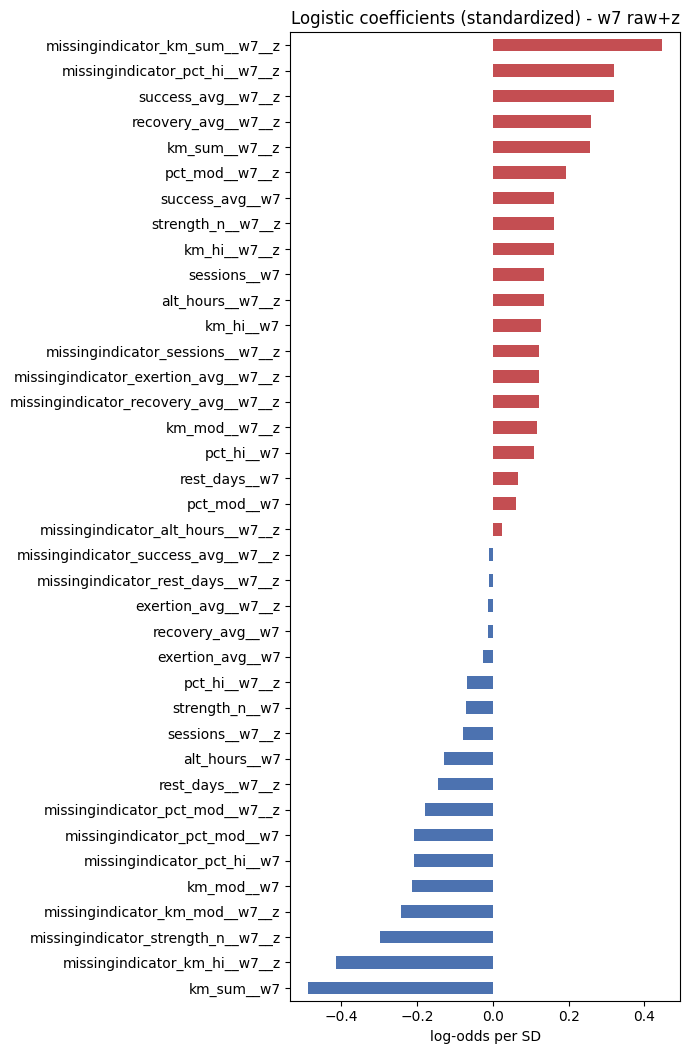

In [8]:
m = logit_pipe(C=0.1)
m.fit(ta_train[FEATS], ta_train.injury)
names = list(m.named_steps['impute'].get_feature_names_out(FEATS))
coefs = pd.Series(m.named_steps['clf'].coef_[0], index=names).sort_values()
fig, ax = plt.subplots(figsize=(7, max(4, .28 * len(coefs))))
coefs.plot.barh(ax=ax, color=np.where(coefs < 0, '#4C72B0', '#C44E52'))
ax.set_title(f'Logistic coefficients (standardized) - {BEST}')
ax.set_xlabel('log-odds per SD')
plt.tight_layout()

## Summary

- Feature-set comparison answers the paper-gap question directly: per-athlete
  normalization is the ingredient worth having, exactly as the paper's design implies.
- Winners chosen by the pre-registered AP rule and saved with the paper's benchmark
  alongside, for 04 to test once on the locked splits.
- Two documented corrections upstream (chronic-load leak, window misalignment) are
  why these numbers can be trusted more than v1's spectacular ones.